# ISCRAM2013

Joplin 2011

---

## A. Original description

#### Meta Information:

- We used paid workers from the Crowdflower crowdsourcing platform for labeling
- At least three different workers were required to agree on a label before a task is finalized
- We ran two tasks (as described below) for labeling


####  Task # 1 Categories---Description:

1. Personal Only---if a message is only of interest to its author and her immediate circle of family/friends and does not convey any useful information to other people who do not know the author.
2. Informative (Direct)--- if the message is of interest to other people beyond the author's immediate circle, and seems to be written by a person who is a direct eyewitness of what is taking place.
3. Informative (Indirect)--- if the message is of interest to other people beyond the author's immediate circle, and seems to be seen/heard by the person on the radio, TV, newspaper, or other source. The message must specify the source.
4. Informative (Direct or Indirect)--- if the message is of interest to other people beyond the author's immediate circle, but there is not enough information to tell if it is a direct report or a repetition of something from another source.
5. Other--- if the message is not in English, or if it cannot be classified.


####  Task # 2 Categories---Description:

1. Caution and advice---if a message conveys/reports information about some warning or a piece of advice about a possible hazard of an incident.
2. Casualties and damage---if a message reports the information about casualties or damage done by an incident.
3. Donations of money, goods or services---if a message speaks about money raised, donation offers, goods/services offered or asked by the victims of an incident.
4. People missing, found, or seen---if a message reports about the missing or found person effected by an incident or seen a celebrity visit on ground zero.
5. Information source---if a message conveys/contains some information sources like photo, footage, video, or mentions other sources like TV, radio related to an incident.

####  Task # 3 Sub-Categories from Task 2

- We do not need

#### Reference

Muhammad Imran, Shady Elbassuoni, Carlos Castillo, Fernando Diaz and Patrick Meier. Extracting Information Nuggets from Disaster-Related Messages in Social Media. In Proc. of the 10th International Conference on Information Systems for Crisis Response and Management (ISCRAM), May 2013, Baden-Baden, Germany.

## B. Overview

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import random
random.seed(42)

from dotenv import load_dotenv
load_dotenv()
datasets_path = Path(os.getenv("DATASETS_PATH"))

In [2]:
dataset_path = datasets_path / 'ISCRAM2013' / 'ISCRAM2013_dataset' / 'Joplin_2011_labeled_data'

files = [
    '01_personal-informative-other/a131709.csv',
    '02_informative_caution-infosrc-donation-damage-other/a121571.csv',
    # '03_caution-n-advice_classify-extract/a122047.csv',
    # '03_damage-n-casualties_classify-extract/a126730.csv',
    # '03_donation-help_classify-extract/a126728.csv',
    # '03_infosrc_classify-extract/a122582.csv',
]

### Task 1

In [3]:
filepath = dataset_path / files[0]

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

df_t1 = pd.read_csv(filepath)
df_t1.columns = df_t1.columns.str.strip()

df_t1 = df_t1[df_t1['_golden'] == False]

df_t1.rename(columns={'tweet': 'tweet_text'}, inplace=True)
df_t1['relevant'] = df_t1['choose_one'].apply(lambda x: False if x == 'Other' else True)
df_t1.rename(columns={'choose_one': 'original_relevant_label'}, inplace=True)

df_t1 = df_t1[['relevant', 'tweet_text']]
df_t1["tweet_id"] = [
    random.randint(99000000000000000000, 99999999999999999999) for _ in range(len(df_t1))
]
df_t1['humanitarian_label'] = np.nan
df_t1['original_humanitarian_label'] = np.nan
df_t1['event_type'] = 'storm'
df_t1['dataset'] = 'ISCRAM13'
df_t1['year'] = 2011
df_t1['event_name'] = '2011 Joplin tornado'
df_t1['meta'] = np.nan

In [4]:
df_t1.head()

,relevant,tweet_text,tweet_id,humanitarian_label,original_humanitarian_label,event_type,dataset,year,event_name,meta
0,True,Cruuuuud. Tornado warning for Denton County. A...,99128355989445507485,NaN,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN
2,True,RT @AmandaSalinas: Tornado on the ground in Az...,99854949519964969681,NaN,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN
4,True,US tornado toll rises to 122 (AFP) http://dlvr...,99282341088111907415,NaN,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN
5,True,Tornado sirens. This is scary.,99160876273137374942,NaN,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN
6,True,Sitting in shelter waiting to see if the torna...,99118168890076913833,NaN,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN


### Task 2

In [5]:
filepath = dataset_path / files[1]

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

df_t2 = pd.read_csv(filepath)
df_t2.columns = df_t2.columns.str.strip()
df_t2 = df_t2[df_t2['_golden'] == False]

df_t2.head()

df_t2.rename(columns={'choose_one': 'original_humanitarian_label', 'id': 'tweet_id', 'text': 'tweet_text'}, inplace=True)
df_t2 = df_t2[['original_humanitarian_label', 'tweet_id', 'tweet_text']]
df_t2['humanitarian_label'] = df_t2['original_humanitarian_label']
df_t2['relevant'] = df_t2['original_humanitarian_label'].apply(lambda x: False if x == 'Unknown' else True)
df_t2['original_relevant_label'] = np.nan
df_t2['event_type'] = 'storm'
df_t2['dataset'] = 'ISCRAM13'
df_t2['year'] = 2011
df_t2['event_name'] = '2011 Joplin tornado'
df_t2['meta'] = np.nan


In [6]:
df_t2.head()

,original_humanitarian_label,tweet_id,tweet_text,humanitarian_label,relevant,original_relevant_label,event_type,dataset,year,event_name,meta
0,Caution and advice,74943468706873200,Yesterday was supposed to be 70 and sunny/cold...,Caution and advice,True,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN
1,Information source,74301096193040304,@fox12weather re: tornado. I live in Vancouver...,Information source,True,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN
2,"Donations of money, goods or services",77764430137536400,@TippingPointSEO: please follow my friends @R...,"Donations of money, goods or services",True,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN
3,Casualties and damage,77449750374395904,"My house was blown away by a tornado, but a fa...",Casualties and damage,True,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN
4,Caution and advice,76134461049274304,@Juss2Live: News was goin crazy about tornado...,Caution and advice,True,NaN,storm,ISCRAM13,2011,2011 Joplin tornado,NaN


In [7]:
df_t2['humanitarian_label'].value_counts()

humanitarian_label
Caution and advice                       416
Information source                       273
Donations of money, goods or services    191
Casualties and damage                    127
Unknown                                  124
People missing, found or seen             40
Name: count, dtype: int64

#### B.3. Concat Dataset

In [ ]:
import csv
df = pd.concat([df_t1, df_t2], ignore_index=True)
df.to_csv('../data/datasets/ISCRAM2013.csv', index=False, quoting=csv.QUOTE_ALL)

<Axes: xlabel='relevant'>

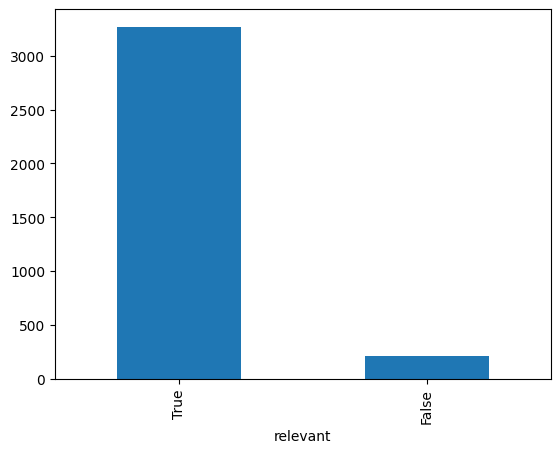

In [9]:
df['relevant'].value_counts().plot(kind='bar')

<Axes: xlabel='humanitarian_label'>

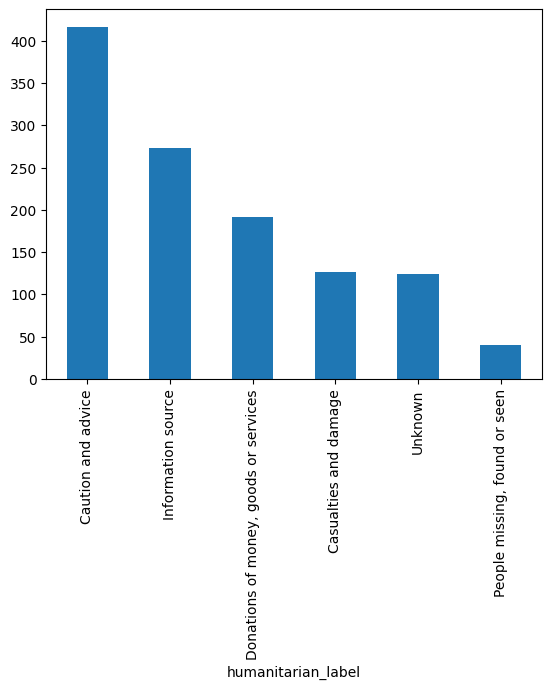

In [10]:
df['humanitarian_label'].value_counts().plot(kind='bar')